This ensures that our system suitably describes a plasma such that Debye shielding can take place.

In [102]:
import numpy as np
import math

def validateDomain(dx, dy, dz, ne, kT):
  eps0 = 8.854e-12 #in Farads per meter
  qe = -1.602e-19 #in Coulombs
  lamD = math.sqrt((eps0*kT)/(ne*abs(qe))) #Debye length

  return max(dx, dy, dz) < lamD

Prints out values for charge, particle number, total energy, and momentum for the system, meant to serve as a check as to conserved quantities.

In [103]:
import numpy as np

def checkConservationLaws(eps0, m_e, m_i, W_e, W_i, dx, dy, dz, pxe, pxi, vxe, vye, vze, vxi, vyi, vzi, rho, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z):
  #Conservation of charge check
  print("Conservation of Charge")
  total_charge = np.sum(rho)*dx*dy*dz
  print(total_charge)

  #Conservation of particle number check
  print("Conservation of Particle Number")
  print(len(pxe))
  print(len(pxi))

  #Conservation of momentum check
  print("Conservation of Momentum")
  Px = m_e*W_e*np.sum(vxe) + m_i*W_i*np.sum(vxi)
  Py = m_e*W_e*np.sum(vye) + m_i*W_i*np.sum(vyi)
  Pz = m_e*W_e*np.sum(vze) + m_i*W_i*np.sum(vzi)
  print(Px)
  print(Py)
  print(Pz)

  #Conservation of energy check
  print("Conservation of Energy")
  KE_e = 0.5*m_e*W_e*np.sum(vxe**2 + vye**2 + vze**2)
  KE_i = 0.5*m_i*W_i*np.sum(vxi**2 + vyi**2 + vzi**2)
  PE = (0.5*eps0*np.sum(EFieldGrid_x**2 + EFieldGrid_y**2 + EFieldGrid_z**2)*dx*dy*dz)
  print(KE_e + KE_i + PE)

  return Px, Py, Pz, KE_e + KE_i + PE

Animate E-Field for the gridpoints and animate particle trajectories.

In [104]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def animate(t, L_x, L_y, L_z, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, electron_traj_x, electron_traj_y, electron_traj_z, ion_traj_x, ion_traj_y, ion_traj_z):
  if t % 10 == 0:
    xGrid = np.linspace(0, L_x, nx)
    yGrid = np.linspace(0, L_y, ny)
    zGrid = np.linspace(0, L_z, nz)

    X, Y, Z = np.meshgrid(xGrid, yGrid, zGrid, indexing='ij')
    step = 3

    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(111, projection='3d')

    ax.quiver(X[::step,::step,::step], Y[::step,::step,::step], Z[::step,::step,::step], EFieldGrid_x[::step,::step,::step], EFieldGrid_y[::step,::step,::step], EFieldGrid_z[::step,::step,::step], length=0.01, normalize=True)

    num_show = 2  # don't plot all 1000 particles

    for p in range(num_show):
        ax.plot(np.array(electron_traj_x)[:,p], np.array(electron_traj_y)[:,p], np.array(electron_traj_z)[:,p], linewidth=1)

    for p in range(num_show):
        ax.plot(np.array(ion_traj_x)[:,p], np.array(ion_traj_y)[:,p], np.array(ion_traj_z)[:,p], linewidth=1)

    ax.set_xlim(0, L_x)
    ax.set_ylim(0, L_y)
    ax.set_zlim(0, L_z)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    ax.set_title(f"Electric Field at timestep {t}")
    plt.show()


This protects our boundary conditions and ensures that particles at the boundaries are reflected internally.

In [105]:
import numpy as np

def boundaryCondition(L_x, L_y, L_z, px, py, pz, vx, vy, vz, Num):
  for p in range(Num):
    # x-direction reflection
    while px[p] < 0 or px[p] > L_x:
        if px[p] < 0:
            px[p] = -px[p]
            vx[p] *= -1

        elif px[p] > L_x:
            px[p] = 2*L_x - px[p]
            vx[p] *= -1

    # y-direction reflection
    while py[p] < 0 or py[p] > L_y:
        if py[p] < 0:
            py[p] = -py[p]
            vy[p] *= -1

        elif py[p] > L_y:
            py[p] = 2*L_y - py[p]
            vy[p] *= -1

    # z-direction reflection
    while pz[p] < 0 or pz[p] > L_z:
        if pz[p] < 0:
            pz[p] = -pz[p]
            vz[p] *= -1

        elif pz[p] > L_z:
            pz[p] = 2*L_z - pz[p]
            vz[p] *= -1

  return px, py, pz, vx, vy, vz

This constructs our charge density via cloud-in-cell weighting.

In [106]:
import numpy as np
import math

def depositCharge(dx, dy, dz, nx, ny, nz, Q, px, py, pz, Num, rho):
  i = np.clip((px / dx).astype(int), 0, nx - 2)
  j = np.clip((py / dy).astype(int), 0, ny - 2)
  k = np.clip((pz / dz).astype(int), 0, nz - 2)

  sx = (px - i*dx)/dx
  sy = (py - j*dy)/dy
  sz = (pz - k*dz)/dz

  w000 = (1-sx)*(1-sy)*(1-sz)
  w100 = sx*(1-sy)*(1-sz)
  w010 = (1-sx)*sy*(1-sz)
  w110 = sx*sy*(1-sz)
  w001 = (1-sx)*(1-sy)*sz
  w101 = sx*(1-sy)*sz
  w011 = (1-sx)*sy*sz
  w111 = sx*sy*sz

  np.add.at(rho, (i,   j,   k  ), Q*w000)
  np.add.at(rho, (i+1, j,   k  ), Q*w100)
  np.add.at(rho, (i,   j+1, k  ), Q*w010)
  np.add.at(rho, (i+1, j+1, k  ), Q*w110)
  np.add.at(rho, (i,   j,   k+1), Q*w001)
  np.add.at(rho, (i+1, j,   k+1), Q*w101)
  np.add.at(rho, (i,   j+1, k+1), Q*w011)
  np.add.at(rho, (i+1, j+1, k+1), Q*w111)

def findRhoGrid(dx, dy, dz, nx, ny, nz, Q_e, Q_i, pxi, pyi, pzi, pxe, pye, pze, Num_e, Num_i, rho):
  rho.fill(0)
  depositCharge(dx, dy, dz, nx, ny, nz, Q_e, pxe, pye, pze, Num_e, rho)
  depositCharge(dx, dy, dz, nx, ny, nz, Q_i, pxi, pyi, pzi, Num_i, rho)
  rho /= dx*dy*dz
  return rho


We have three constructions for phi (relative to the grid points) using three methods:

-Method 1: Jacobi

-Method 2: Gauss-Seidel

-Method 3: Successive Over-relaxation (SOR)

In [107]:
import numpy as np
import math

def findPhiGridMethod1(dx, dy, dz, nx, ny, nz, rho, max_iter, tolerance, phi):
  eps0 = 8.854e-12 #in Farads per meter
  phi_old = phi.copy()
  phi_new = phi.copy()

  for l in range(max_iter):
    max_change = 0
    for i in range(1, nx-1):
        for j in range(1, ny-1):
            for k in range(1, nz-1):
              comparePhi = phi_new[i,j,k]
              phi_new[i,j,k] = (rho[i,j,k]/eps0 + (phi_old[i-1,j,k] + phi_old[i+1,j,k])/dx**2 + (phi_old[i,j-1,k] + phi_old[i,j+1,k])/dy**2 + (phi_old[i,j,k-1] + phi_old[i,j,k+1])/dz**2)/(2/dx**2 + 2/dy**2 + 2/dz**2)
              change = abs(phi_new[i,j,k] - comparePhi)
              max_change = max(max_change, change)
    if max_change < tolerance:
      break
    phi_old, phi_new = phi_new, phi_old
  return phi_old, l+1

def findPhiGridMethod2(dx, dy, dz, nx, ny, nz, rho,
                       max_iter, tolerance, phi):

    eps0 = 8.854e-12  # F/m

    for l in range(max_iter):

        max_change = 0.0

        for i in range(1, nx-1):
            for j in range(1, ny-1):
                for k in range(1, nz-1):
                    oldPhi = phi[i,j,k]
                    phi[i,j,k] = (rho[i,j,k]/eps0 + (phi[i-1,j,k] + phi[i+1,j,k])/dx**2 + (phi[i,j-1,k] + phi[i,j+1,k])/dy**2 + (phi[i,j,k-1] + phi[i,j,k+1])/dz**2) / (2/dx**2 + 2/dy**2 + 2/dz**2)
                    change = abs(phi[i,j,k] - oldPhi)

                    if change > max_change:
                        max_change = change
        if max_change < tolerance:
            return phi, l+1
    return phi, max_iter

def findPhiGridMethod3(dx, dy, dz, nx, ny, nz, rho, max_iter, tolerance, phi, omega):
  eps0 = 8.854e-12 #in Farads per meter

  max_change = 0

  for l in range(max_iter):
    max_change = 0
    for i in range(1, nx-1):
        for j in range(1, ny-1):
            for k in range(1, nz-1):
              oldPhi = phi[i,j,k]
              phiGS =  (rho[i,j,k]/eps0 + (phi[i-1,j,k] + phi[i+1,j,k])/dx**2 + (phi[i,j-1,k] + phi[i,j+1,k])/dy**2 + (phi[i,j,k-1] + phi[i,j,k+1])/dz**2)/(2/dx**2 + 2/dy**2 + 2/dz**2)
              phi[i,j,k] = (1-omega)*oldPhi + omega*phiGS
              change = abs(phi[i,j,k] - oldPhi)
              max_change = max(max_change, change)
    if max_change < tolerance:
      return phi, l+1
  return phi, max_iter


Once \phi is found, the E-field for the grid points follows suit using centered finite differences formula.

In [108]:
import numpy as np

def findElectricFieldGrid(dx, dy, dz, nx, ny, nz, phi, EGrid_x, EGrid_y, EGrid_z):
  for i in range(1, nx-1):
        for j in range(1, ny-1):
            for k in range(1, nz-1):

                EGrid_x[i,j,k] = -(phi[i+1,j,k] - phi[i-1,j,k])/(2*dx)

                EGrid_y[i,j,k] = -(phi[i,j+1,k] - phi[i,j-1,k])/(2*dy)

                EGrid_z[i,j,k] = -(phi[i,j,k+1] - phi[i,j,k-1])/(2*dz)

  return EGrid_x, EGrid_y, EGrid_z

Once we have the E-field for gridpoints, we can basically do a backwards implementation of cloud-in-cell weighting.

In [109]:
import numpy as np

def supplyEField(dx, dy, dz, nx, ny, nz, px, py, pz, EGrid_x, EGrid_y, EGrid_z, Num, Epx, Epy, Epz):
  i = np.clip((px / dx).astype(int), 0, nx - 2)
  j = np.clip((py / dy).astype(int), 0, ny - 2)
  k = np.clip((pz / dz).astype(int), 0, nz - 2)

  sx = (px - i*dx)/dx
  sy = (py - j*dy)/dy
  sz = (pz - k*dz)/dz

  w000 = (1-sx)*(1-sy)*(1-sz)
  w100 = sx*(1-sy)*(1-sz)
  w010 = (1-sx)*sy*(1-sz)
  w110 = sx*sy*(1-sz)
  w001 = (1-sx)*(1-sy)*sz
  w101 = sx*(1-sy)*sz
  w011 = (1-sx)*sy*sz
  w111 = sx*sy*sz

  Epx = (w000*EGrid_x[i,  j,  k] + w100*EGrid_x[i+1,j,  k] + w010*EGrid_x[i,j+1,k] + w110*EGrid_x[i+1,j+1,k] + w001*EGrid_x[i,  j,  k+1] + w101*EGrid_x[i+1,j,  k+1] +w011*EGrid_x[i,  j+1,k+1] + w111*EGrid_x[i+1,j+1,k+1])
  Epy = (w000*EGrid_y[i,  j,  k] + w100*EGrid_y[i+1,j,  k] + w010*EGrid_y[i,  j+1,k] + w110*EGrid_y[i+1,j+1,k] + w001*EGrid_y[i,  j,  k+1] + w101*EGrid_y[i+1,j,  k+1] +w011*EGrid_y[i,  j+1,k+1] + w111*EGrid_y[i+1,j+1,k+1])
  Epz = (w000*EGrid_z[i,  j,  k] + w100*EGrid_z[i+1,j,  k] + w010*EGrid_z[i,  j+1,k] + w110*EGrid_z[i+1,j+1,k] + w001*EGrid_z[i,  j,  k+1] + w101*EGrid_z[i+1,j,  k+1] +w011*EGrid_z[i,  j+1,k+1] + w111*EGrid_z[i+1,j+1,k+1])

  return Epx, Epy, Epz

def findElectricFieldParticles(dx, dy, dz, nx, ny, nz, pxi, pyi, pzi, pxe, pye, pze, EGrid_x, EGrid_y, EGrid_z, Num_e, Num_i, Epx_e, Epy_e, Epz_e, Epx_i, Epy_i, Epz_i):
  Epx_e, Epy_e, Epz_e = supplyEField(dx, dy, dz, nx, ny, nz, pxe, pye, pze, EGrid_x, EGrid_y, EGrid_z, Num_e, Epx_e, Epy_e, Epz_e)
  Epx_i, Epy_i, Epz_i = supplyEField(dx, dy, dz, nx, ny, nz, pxi, pyi, pzi, EGrid_x, EGrid_y, EGrid_z, Num_i, Epx_i, Epy_i, Epz_i)

  return Epx_e, Epy_e, Epz_e, Epx_i, Epy_i, Epz_i

We have three constructions for timestepping using three methods:

-Method 1: Forward-Euler

-Method 2: Leapfrog

-Method 3: Boris Pusher

In [110]:
import numpy as np

def timestepMethod1(q_e, q_i, Q_e, Q_i, m_e, m_i, Num_e, Num_i, L_x, L_y, L_z, dx, dy, dz, nx, ny, nz, pxe, pye, pze, pxi, pyi, pzi, vxe, vye, vze, vxi, vyi, vzi, EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i, B_x, B_y, B_z, rho, phiGrid, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, dt):
  axe = (q_e/m_e)*(EFieldParticles_x_e
                   + vye*B_z - vze*B_y)
  aye = (q_e/m_e)*(EFieldParticles_y_e
                   + vze*B_x - vxe*B_z)
  aze = (q_e/m_e)*(EFieldParticles_z_e
                   + vxe*B_y - vye*B_x)
  vxe += axe*dt
  vye += aye*dt
  vze += aze*dt
  pxe += vxe*dt
  pye += vye*dt
  pze += vze*dt

  axi = (q_i/m_i)*(EFieldParticles_x_i
                   + vyi*B_z - vzi*B_y)
  ayi = (q_i/m_i)*(EFieldParticles_y_i
                   + vzi*B_x - vxi*B_z)
  azi = (q_i/m_i)*(EFieldParticles_z_i
                   + vxi*B_y - vyi*B_x)
  vxi += axi*dt
  vyi += ayi*dt
  vzi += azi*dt
  pxi += vxi*dt
  pyi += vyi*dt
  pzi += vzi*dt

  pxe, pye, pze, vxe, vye, vze = boundaryCondition(L_x, L_y, L_z, pxe, pye, pze, vxe, vye, vze, Num_e)
  pxi, pyi, pzi, vxi, vyi, vzi = boundaryCondition(L_x, L_y, L_z, pxi, pyi, pzi, vxi, vyi, vzi, Num_i)

  rho = findRhoGrid(dx, dy, dz, nx, ny, nz, Q_e, Q_i, pxi, pyi, pzi, pxe, pye, pze, Num_e, Num_i, rho)
  phiGrid, iter = findPhiGridMethod3(dx, dy, dz, nx, ny, nz, rho, 1000, 1e-8, phiGrid, 1.75)
  EFieldGrid_x, EFieldGrid_y, EFieldGrid_z = findElectricFieldGrid(dx, dy, dz, nx, ny, nz, phiGrid, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z)
  EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i = findElectricFieldParticles(dx, dy, dz, nx, ny, nz, pxi, pyi, pzi, pxe, pye, pze, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, Num_e, Num_i, EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i)

  return pxe, pye, pze, pxi, pyi, pzi, vxe, vye, vze, vxi, vyi, vzi, rho, phiGrid, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i, iter

def timestepMethod2(q_e, q_i, Q_e, Q_i, m_e, m_i, L_x, L_y, L_z, dx, dy, dz, nx, ny, nz, Num_e, Num_i, pxe, pye, pze, pxi, pyi, pzi, vxe_half, vye_half, vze_half, vxi_half, vyi_half, vzi_half, axe, aye, aze, axi, ayi, azi, rho, phiGrid, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i, dt):
  vxe_half += axe*dt
  vye_half += aye*dt
  vze_half += aze*dt
  vxi_half += axi*dt
  vyi_half += ayi*dt
  vzi_half += azi*dt

  pxe += vxe_half*dt
  pye += vye_half*dt
  pze += vze_half*dt
  pxi += vxi_half*dt
  pyi += vyi_half*dt
  pzi += vzi_half*dt

  pxe, pye, pze, vxe_half, vye_half, vze_half = boundaryCondition(L_x, L_y, L_z, pxe, pye, pze, vxe_half, vye_half, vze_half, Num_e)
  pxi, pyi, pzi, vxi_half, vyi_half, vzi_half = boundaryCondition(L_x, L_y, L_z, pxi, pyi, pzi, vxi_half, vyi_half, vzi_half, Num_i)

  rho = findRhoGrid(dx, dy, dz, nx, ny, nz, Q_e, Q_i, pxi, pyi, pzi, pxe, pye, pze, Num_e, Num_i, rho)
  phiGrid, iter = findPhiGridMethod3(dx, dy, dz, nx, ny, nz, rho, 1000, 1e-8, phiGrid, 1.75)
  EFieldGrid_x, EFieldGrid_y, EFieldGrid_z = findElectricFieldGrid(dx, dy, dz, nx, ny, nz, phiGrid, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z)
  EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i = findElectricFieldParticles(dx, dy, dz, nx, ny, nz, pxi, pyi, pzi, pxe, pye, pze, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, Num_e, Num_i, EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i)

  axe = (q_e/m_e)*(EFieldParticles_x_e + vye_half*B_z - vze_half*B_y)
  aye = (q_e/m_e)*(EFieldParticles_y_e + vze_half*B_x - vxe_half*B_z)
  aze = (q_e/m_e)*(EFieldParticles_z_e + vxe_half*B_y - vye_half*B_x)
  axi = (q_i/m_i)*(EFieldParticles_x_i + vyi_half*B_z - vzi_half*B_y)
  ayi = (q_i/m_i)*(EFieldParticles_y_i + vzi_half*B_x - vxi_half*B_z)
  azi = (q_i/m_i)*(EFieldParticles_z_i + vxi_half*B_y - vyi_half*B_x)

  return pxe, pye, pze, pxi, pyi, pzi, vxe_half, vye_half, vze_half, vxi_half, vyi_half, vzi_half, axe, aye, aze, axi, ayi, azi, rho, phiGrid, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i, iter

def timestepMethod3(m_e, m_i, q_e, q_i, Q_e, Q_i, pxe, pye, pze, pxi, pyi, pzi, vxe, vye, vze, vxi, vyi, vzi, rho, phiGrid, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i, B_x, B_y, B_z, dt):
  vxe_minus = vxe + (q_e/m_e)*EFieldParticles_x_e*dt/2
  vye_minus = vye + (q_e/m_e)*EFieldParticles_y_e*dt/2
  vze_minus = vze + (q_e/m_e)*EFieldParticles_z_e*dt/2
  vxi_minus = vxi + (q_i/m_i)*EFieldParticles_x_i*dt/2
  vyi_minus = vyi + (q_i/m_i)*EFieldParticles_y_i*dt/2
  vzi_minus = vzi + (q_i/m_i)*EFieldParticles_z_i*dt/2

  txe = (q_e/m_e)*B_x*dt/2
  tye = (q_e/m_e)*B_y*dt/2
  tze = (q_e/m_e)*B_z*dt/2
  txi = (q_i/m_i)*B_x*dt/2
  tyi = (q_i/m_i)*B_y*dt/2
  tzi = (q_i/m_i)*B_z*dt/2

  vxe_prime = vxe_minus + (vye_minus*tze - vze_minus*tye)
  vye_prime = vye_minus + (vze_minus*txe - vxe_minus*tze)
  vze_prime = vze_minus + (vxe_minus*tye - vye_minus*txe)
  vxi_prime = vxi_minus + (vyi_minus*tzi - vzi_minus*tyi)
  vyi_prime = vyi_minus + (vzi_minus*txi - vxi_minus*tzi)
  vzi_prime = vzi_minus + (vxi_minus*tyi - vyi_minus*txi)

  sxe = (2*txe)/(1 + txe**2 + tye**2 + tze**2)
  sye = (2*tye)/(1 + txe**2 + tye**2 + tze**2)
  sze = (2*tze)/(1 + txe**2 + tye**2 + tze**2)
  sxi = (2*txi)/(1 + txi**2 + tyi**2 + tzi**2)
  syi = (2*tyi)/(1 + txi**2 + tyi**2 + tzi**2)
  szi = (2*tzi)/(1 + txi**2 + tyi**2 + tzi**2)

  vxe_plus = vxe_minus + (vye_prime*sze - vze_prime*sye)
  vye_plus = vye_minus + (vze_prime*sxe - vxe_prime*sze)
  vze_plus = vze_minus + (vxe_prime*sye - vye_prime*sxe)
  vxi_plus = vxi_minus + (vyi_prime*szi - vzi_prime*syi)
  vyi_plus = vyi_minus + (vzi_prime*sxi - vxi_prime*szi)
  vzi_plus = vzi_minus + (vxi_prime*syi - vyi_prime*sxi)

  vxe = vxe_plus + (q_e/m_e)*EFieldParticles_x_e*dt/2
  vye = vye_plus + (q_e/m_e)*EFieldParticles_y_e*dt/2
  vze = vze_plus + (q_e/m_e)*EFieldParticles_z_e*dt/2
  vxi = vxi_plus + (q_i/m_i)*EFieldParticles_x_i*dt/2
  vyi = vyi_plus + (q_i/m_i)*EFieldParticles_y_i*dt/2
  vzi = vzi_plus + (q_i/m_i)*EFieldParticles_z_i*dt/2

  pxe += vxe*dt
  pye += vye*dt
  pze += vze*dt
  pxi += vxi*dt
  pyi += vyi*dt
  pzi += vzi*dt

  pxe, pye, pze, vxe, vye, vze = boundaryCondition(L_x, L_y, L_z, pxe, pye, pze, vxe, vye, vze, Num_e)
  pxi, pyi, pzi, vxi, vyi, vzi = boundaryCondition(L_x, L_y, L_z, pxi, pyi, pzi, vxi, vyi, vzi, Num_i)

  rho = findRhoGrid(dx, dy, dz, nx, ny, nz, Q_e, Q_i, pxi, pyi, pzi, pxe, pye, pze, Num_e, Num_i, rho)
  phiGrid, iter = findPhiGridMethod3(dx, dy, dz, nx, ny, nz, rho, 1000, 1e-8, phiGrid, 1.75)
  EFieldGrid_x, EFieldGrid_y, EFieldGrid_z = findElectricFieldGrid(dx, dy, dz, nx, ny, nz, phiGrid, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z)
  EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i = findElectricFieldParticles(dx, dy, dz, nx, ny, nz, pxi, pyi, pzi, pxe, pye, pze, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, Num_e, Num_i, EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i)

  return pxe, pye, pze, pxi, pyi, pzi, vxe, vye, vze, vxi, vyi, vzi, rho, phiGrid, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i, iter

The main body. Notice on the bottom, we have three options for timestepping, two of which are commented out.

Streaming output truncated to the last 5000 lines.
Conservation of Momentum
1.3387523671639164e-16
2.7642159847451505e-17
9.265116913291581e-18
Conservation of Energy
2.357282776553384e-10
Number of timesteps: 117
Number of iterations: 72
Conservation of Charge
2.1902343749999997e-10
Conservation of Particle Number
1000
8000
Conservation of Momentum
1.3458978231928008e-16
2.5302974181365635e-17
7.06542479648633e-18
Conservation of Energy
2.356659700677311e-10
Number of timesteps: 118
Number of iterations: 74
Conservation of Charge
2.1902343749999997e-10
Conservation of Particle Number
1000
8000
Conservation of Momentum
1.333304234714371e-16
2.396259366876682e-17
5.472434771088947e-18
Conservation of Energy
2.355651104854298e-10
Number of timesteps: 119
Number of iterations: 72
Conservation of Charge
2.1902343749999997e-10
Conservation of Particle Number
1000
8000
Conservation of Momentum
1.3231157115847003e-16
2.1769107332735377e-17
2.9465902184496055e-18
Conservation of Energy
2.35503

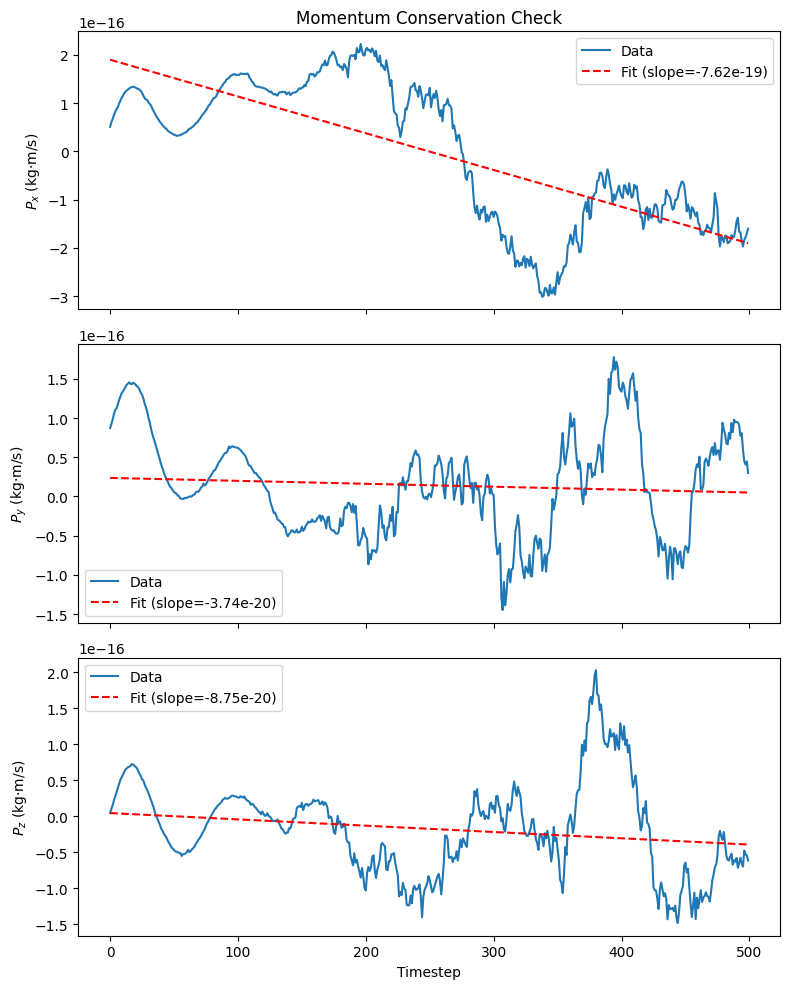

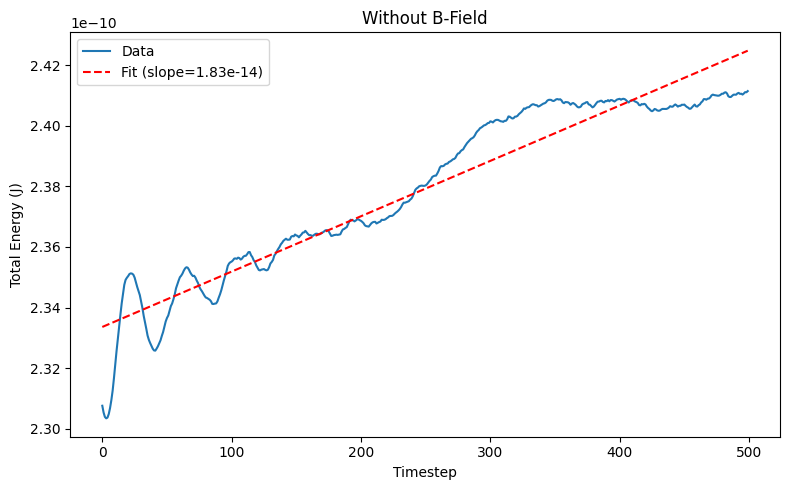

Relative energy drift: 4.507037e-02


In [111]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import time

start = time.perf_counter()

#Domain length per dimension
L_x, L_y, L_z = 0.25, 0.25, 0.25

#Ion and electron densities, number, temperatures, mass, and eps0
density_i, density_e = 1e11, 1e11
num_i, num_e = int((L_x * L_y * L_z)*density_i), int(((L_x / 2) * (L_y / 2) * (L_z / 2))*density_e)
temp_i, temp_e = 0.025, 1 #in eV
m_i, m_e = 1.67e-27, 9.11e-31 #in kg
q_i, q_e = 1.602e-19, -1.602e-19 #in C
eps0 = 8.854e-12 #in Farads per meter

#Introduce macroparticles (don't want to blow up my Chromebook)
Num_e = 1000
Num_i = int((num_i/num_e)*Num_e)
W_e, W_i = num_e/Num_e, num_i/Num_i
Q_e, Q_i = W_e*q_e, W_i*q_i

#Number of grid points per dimension
nx, ny, nz = 21, 21, 21

#Spacing per cell
dx, dy, dz = L_x/(nx-1), L_y/(ny-1), L_z/(nz-1)

#Gridspace per dimension
xGrid, yGrid, zGrid = np.linspace(0, L_x, nx), np.linspace(0, L_y, ny), np.linspace(0, L_z, nz)
X, Y, Z = np.meshgrid(L_x, L_y, L_z, indexing='ij')

#Number of iterations and timestep
max_iterations = 500
dt = 1e-8

#Initial position and speed distribution
pxi = np.random.uniform(0, L_x, Num_i) #x-position for ions
pyi = np.random.uniform(0, L_y, Num_i) #y-position for ions
pzi = np.random.uniform(0, L_z, Num_i) #z-position for ions
pxe = np.random.uniform(0, L_x / 2, Num_e) #x-position for electrons
pye = np.random.uniform(0, L_y / 2, Num_e) #y-position for electrons
pze = np.random.uniform(0, L_z / 2, Num_e) #z-position for electrons
vxi = np.random.normal(0, np.sqrt(temp_i*q_i/m_i), Num_i) #x-velocity for ions
vyi = np.random.normal(0, np.sqrt(temp_i*q_i/m_i), Num_i) #y-velocity for ions
vzi = np.random.normal(0, np.sqrt(temp_i*q_i/m_i), Num_i) #z-velocity for ions
vxe = np.random.normal(0, np.sqrt(temp_e*q_i/m_e), Num_e) #x-velocity for electrons
vye = np.random.normal(0, np.sqrt(temp_e*q_i/m_e), Num_e) #y-velocity for electrons
vze = np.random.normal(0, np.sqrt(temp_e*q_i/m_e), Num_e) #z-velocity for electrons

#External Magnetic Field
B_x, B_y, B_z = 0, 0, 0 #in Teslas

if validateDomain(dx, dy, dz, density_e, temp_e) == False:
  print("Domain size does not satisfy max{dx, dy, dz} < lambda_D")
  exit()
else:
  print("Valid Domain")

#Initialization
rho = np.zeros((nx, ny, nz))
phiGrid = np.zeros((nx, ny, nz))
EFieldGrid_x, EFieldGrid_y, EFieldGrid_z = np.zeros((nx, ny, nz)), np.zeros((nx, ny, nz)), np.zeros((nx, ny, nz))
EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i = np.zeros(Num_e), np.zeros(Num_e), np.zeros(Num_e), np.zeros(Num_i), np.zeros(Num_i), np.zeros(Num_i)

rho = findRhoGrid(dx, dy, dz, nx, ny, nz, Q_e, Q_i, pxi, pyi, pzi, pxe, pye, pze, Num_e, Num_i, rho)
phiGrid, iter = findPhiGridMethod3(dx, dy, dz, nx, ny, nz, rho, 1000, 1e-8, phiGrid, 1.75)
EFieldGrid_x, EFieldGrid_y, EFieldGrid_z = findElectricFieldGrid(dx, dy, dz, nx, ny, nz, phiGrid, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z)
EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i = findElectricFieldParticles(dx, dy, dz, nx, ny, nz, pxi, pyi, pzi, pxe, pye, pze, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, Num_e, Num_i, EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i)

#For the sake of plotting particle trajectories, momentum graph
electron_traj_x = []
electron_traj_y = []
electron_traj_z = []
ion_traj_x = []
ion_traj_y = []
ion_traj_z = []
momentum_x = np.zeros(max_iterations)
momentum_y = np.zeros(max_iterations)
momentum_z = np.zeros(max_iterations)
energy = np.zeros(max_iterations)

total_iter = iter
print("Numer of timesteps: 0")
print(f"Number of iterations: {iter}")

"""
#Forward-Euler timestepper
for t in range(max_iterations):
  pxe, pye, pze, pxi, pyi, pzi, vxe, vye, vze, vxi, vyi, vzi, rho, phiGrid, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i, iter = timestepMethod1(q_e, q_i, Q_e, Q_i, m_e, m_i, Num_e, Num_i, L_x, L_y, L_z, dx, dy, dz, nx, ny, nz, pxe, pye, pze, pxi, pyi, pzi, vxe, vye, vze, vxi, vyi, vzi, EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i, B_x, B_y, B_z, rho, phiGrid, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, dt)

  electron_traj_x.append(pxe.copy())
  electron_traj_y.append(pye.copy())
  electron_traj_z.append(pze.copy())

  ion_traj_x.append(pxi.copy())
  ion_traj_y.append(pyi.copy())
  ion_traj_z.append(pzi.copy())

  print(f"Number of timesteps: {t + 1}")
  print(f"Number of iterations: {iter}")
  total_iter += iter
  checkConservationLaws(eps0, m_e, m_i, W_e, W_i, dx, dy, dz, pxe, pxi, vxe, vye, vze, vxi, vyi, vzi, rho, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z)
  animate(t, L_x, L_y, L_z, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, electron_traj_x, electron_traj_y, electron_traj_z, ion_traj_x, ion_traj_y, ion_traj_z)
"""
"""
#Leapfrog timestepper
axe = (q_e/m_e)*(EFieldParticles_x_e + vye*B_z - vze*B_y)
aye = (q_e/m_e)*(EFieldParticles_y_e + vze*B_x - vxe*B_z)
aze = (q_e/m_e)*(EFieldParticles_z_e + vxe*B_y - vye*B_x)
axi = (q_i/m_i)*(EFieldParticles_x_i + vyi*B_z - vzi*B_y)
ayi = (q_i/m_i)*(EFieldParticles_y_i + vzi*B_x - vxi*B_z)
azi = (q_i/m_i)*(EFieldParticles_z_i + vxi*B_y - vyi*B_x)
vxe_half = vxe + 0.5*axe*dt
vye_half = vye + 0.5*aye*dt
vze_half = vze + 0.5*aze*dt
vxi_half = vxi + 0.5*axi*dt
vyi_half = vyi + 0.5*ayi*dt
vzi_half = vzi + 0.5*azi*dt

for t in range(max_iterations):
  pxe, pye, pze, pxi, pyi, pzi, vxe_half, vye_half, vze_half, vxi_half, vyi_half, vzi_half, axe, aye, aze, axi, ayi, azi, rho, phiGrid, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i, iter = timestepMethod2(q_e, q_i, Q_e, Q_i, m_e, m_i, L_x, L_y, L_z, dx, dy, dz, nx, ny, nz, Num_e, Num_i, pxe, pye, pze, pxi, pyi, pzi, vxe_half, vye_half, vze_half, vxi_half, vyi_half, vzi_half, axe, aye, aze, axi, ayi, azi, rho, phiGrid, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i, dt)

  electron_traj_x.append(pxe.copy())
  electron_traj_y.append(pye.copy())
  electron_traj_z.append(pze.copy())

  ion_traj_x.append(pxi.copy())
  ion_traj_y.append(pyi.copy())
  ion_traj_z.append(pzi.copy())

  print(f"Number of timesteps: {t + 1}")
  print(f"Number of iterations: {iter}")
  total_iter += iter
  checkConservationLaws(eps0, m_e, m_i, W_e, W_i, dx, dy, dz, pxe, pxi, vxe_half, vye_half, vze_half, vxi_half, vyi_half, vzi_half, rho, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z)
  animate(t, L_x, L_y, L_z, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, electron_traj_x, electron_traj_y, electron_traj_z, ion_traj_x, ion_traj_y, ion_traj_z)
"""
#Boris Pusher timestepper
for t in range(max_iterations):
  pxe, pye, pze, pxi, pyi, pzi, vxe, vye, vze, vxi, vyi, vzi, rho, phiGrid, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i, iter = timestepMethod3(m_e, m_i, q_e, q_i, Q_e, Q_i, pxe, pye, pze, pxi, pyi, pzi, vxe, vye, vze, vxi, vyi, vzi, rho, phiGrid, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i, B_x, B_y, B_z, dt)

  electron_traj_x.append(pxe.copy())
  electron_traj_y.append(pye.copy())
  electron_traj_z.append(pze.copy())

  ion_traj_x.append(pxi.copy())
  ion_traj_y.append(pyi.copy())
  ion_traj_z.append(pzi.copy())

  print(f"Number of timesteps: {t + 1}")
  print(f"Number of iterations: {iter}")
  total_iter += iter
  momentum_x[t], momentum_y[t], momentum_z[t], energy[t] = checkConservationLaws(eps0, m_e, m_i, W_e, W_i, dx, dy, dz, pxe, pxi, vxe, vye, vze, vxi, vyi, vzi, rho, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z)
  #animate(t, L_x, L_y, L_z, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, electron_traj_x, electron_traj_y, electron_traj_z, ion_traj_x, ion_traj_y, ion_traj_z)

average_iter = total_iter / max_iterations
print(f"Average iterations per timestep: {average_iter:.2f}")
end = time.perf_counter()
print(end - start)

timesteps = np.arange(max_iterations)

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

momentum_data = [
    (momentum_x, r"$P_x$ (kg$\cdot$m/s)"),
    (momentum_y, r"$P_y$ (kg$\cdot$m/s)"),
    (momentum_z, r"$P_z$ (kg$\cdot$m/s)"),
]

for ax, (data, label) in zip(axes, momentum_data):
    ax.plot(timesteps, data, label="Data")

    slope, intercept = np.polyfit(timesteps, data, 1)
    fit_line = slope * timesteps + intercept
    ax.plot(timesteps, fit_line, color='red', linestyle='--', label=f"Fit (slope={slope:.2e})")

    ax.set_ylabel(label)
    ax.legend()

axes[0].set_title("Momentum Conservation Check")
axes[2].set_xlabel("Timestep")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(timesteps, energy, label="Data")

slope, intercept = np.polyfit(timesteps, energy, 1)
fit_line = slope * timesteps + intercept
plt.plot(timesteps, fit_line, color='red', linestyle='--', label=f"Fit (slope={slope:.2e})")

plt.xlabel("Timestep")
plt.ylabel("Total Energy (J)")
plt.title("Without B-Field")
plt.legend()
plt.tight_layout()
plt.show()

relative_drift = abs(energy[-1] - energy[0]) / energy[0]
print(f"Relative energy drift: {relative_drift:.6e}")
